<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
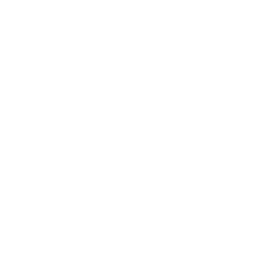
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">用药错误率EWMA趋势分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 医疗健康 / 患者安全 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## Executive Summary

本分析使用PROC MACONTROL提供的**指数加权移动平均（EWMA）控制图**，监测某医院重症监护室（ICU）每周用药错误率。该ICU在观察期第51周上线了新的电子给药记录（eMAR）系统。患者安全团队需要一种预警方法，能在一个季度的伤害报告累积之前，快速标记出错误的持续上升。

平滑权重**lambda = 0.3**的EWMA控制图分两个阶段构建。首先根据稳定的迁移前基线（第1-50周）确定控制限，然后用这些固定限值监测完整的100周序列。控制图在整个基线期内保持受控，并在上线后**第一周**即发出失控信号，证实eMAR迁移与错误率发生真实、持续的变化相吻合，而非普通的周间噪声。

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.ICU_ERRORS | 单个ICU连续100周、每千次给药的每周用药错误率 | 100 |

对单个ICU进行逐周跟踪。每条记录包含周数、每千次给药的错误率、给药量，以及由此推算的错误数。第51周发生了一次记录在案的流程变更（eMAR系统上线），使潜在错误率均值上移约每千次1.6例。

---

In [1]:
/* --------------------------------------------------------
   生成某ICU每周用药错误数据
   连续100周，单个ICU。
   第51周新的电子给药记录（eMAR）系统上线，
   将潜在错误率均值从约3.5提高到约5.1（每千次）。
   -------------------------------------------------------- */
数据 work.icu_errors;
    调用 streaminit(42);
    长度 unit_name $12 phase $20;
    unit_name = 'ICU';
    base_rate  = 3.5;   /* 迁移前的平均错误率（每千次） */
    unit_sigma = 0.45;  /* 周与周之间的普通原因噪声 */
    循环 week_num = 1 到 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        如果 administrations < 300 那么 administrations = 300;
        /* eMAR迁移使第50周之后的均值上移 */
        如果 week_num > 50 那么 循环;
            phase = 'eMAR后';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        结束;
        否则 循环;
            phase = '基线期';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        结束;
        如果 error_rate_per_1k < 0 那么 error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        输出;
    结束;
    删除 base_rate unit_sigma;
    格式 week_start_date date9.;
运行;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                   ICU错误率：基线期与eMAR后对比                                                   

                                                  The MEANS Procedure

                           Analysis Variable : error_rate_per_1k 每千次给药的错误率

        阶段                 N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        eMAR后                 50           5.11           0.44           3.69           5.96
        基线期                   50           3.50           0.48           2.55           4.71
        ------------------------------------------------------------------------------------

                                       Analysis Variable : error_count 错误数

        阶段                 N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


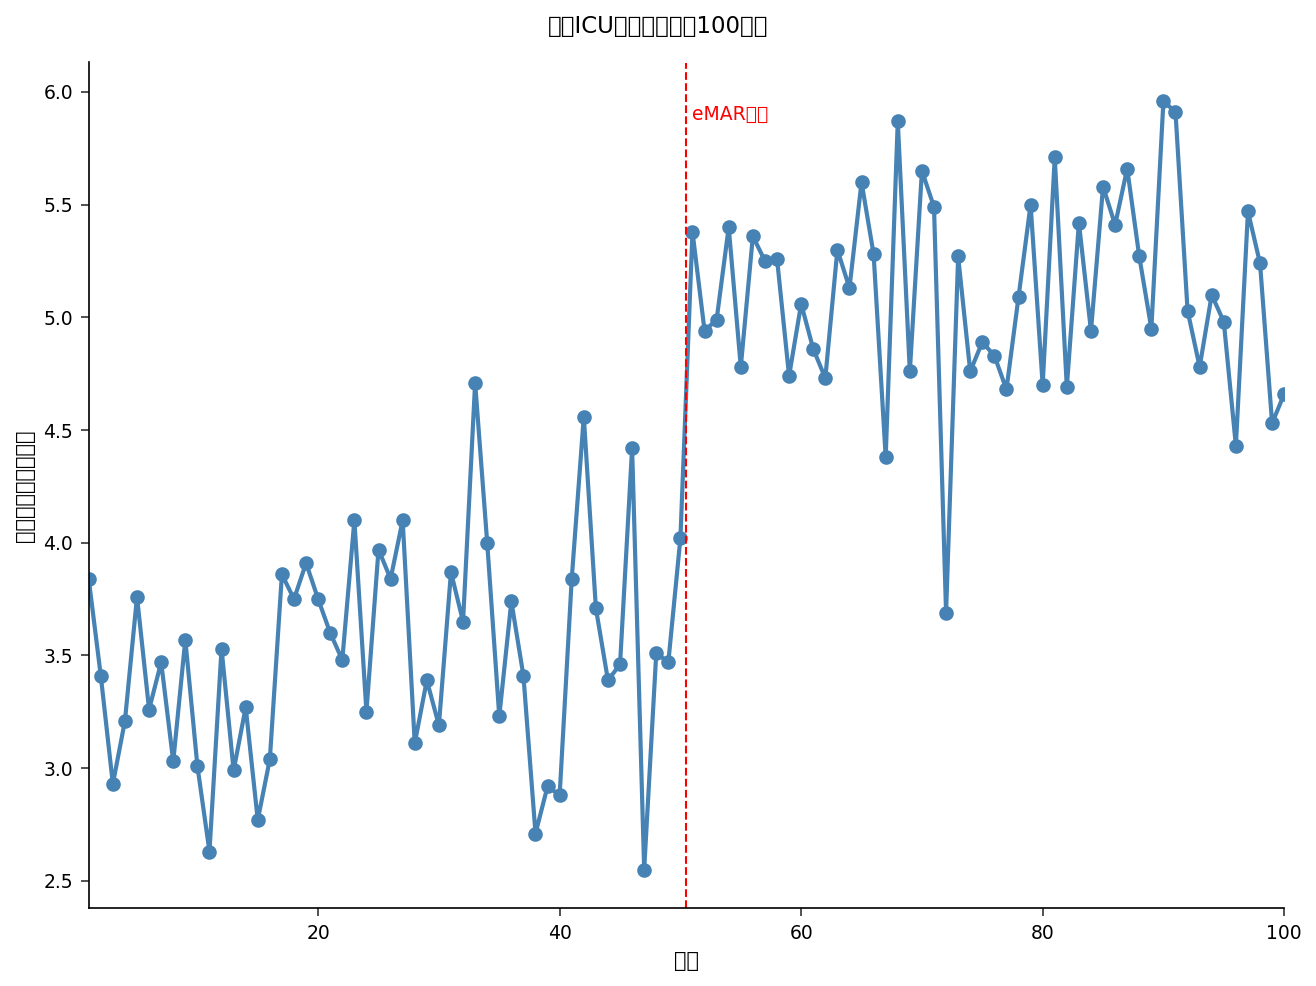

In [2]:
/* --------------------------------------------------------
   比较eMAR上线前后的错误率，并绘制每周趋势图。
   -------------------------------------------------------- */
过程 均值 数据=work.icu_errors n mean std MIN MAX maxdec=2;
    分类 phase;
    变量 error_rate_per_1k error_count administrations;
    标签 error_rate_per_1k = '每千次给药的错误率'
          error_count       = '错误数'
          administrations   = '给药次数'
          phase             = '阶段';
    标题 'ICU错误率：基线期与eMAR后对比';
运行;

过程 SGPLOT 数据=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   标签='eMAR上线';
    XAXIS 标签='周数';
    YAXIS 标签='每千次给药的错误率';
    标题 '每周ICU用药错误率（100周）';
运行;

---

In [3]:
/* --------------------------------------------------------
   第一阶段：根据稳定的迁移前基线（第1-50周）
   建立EWMA控制限。这些固定限值将作为
   整个监测期的评判标准。
   -------------------------------------------------------- */
过程 均值 数据=work.icu_errors(条件=(week_num <= 50)) NOPRINT;
    变量 error_rate_per_1k;
    输出 out=work.baseline_stats mean=base_mean std=base_std;
运行;

数据 work.icu_limits;
    设置 work.baseline_stats;
    长度 _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* 基线中心线 */
    _STDDEV_ = base_std;    /* 基线普通原因标准差 */
    _LIMITN_ = 1;
    保留 _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
运行;

过程 打印 数据=work.icu_limits noobs;
    标题 '第一阶段控制限输入（基线第1-50周）';
运行;

                                                  第一阶段控制限输入（基线第1-50周）                                                   

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                                  第一阶段控制限输入（基线第1-50周）                                                   


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/6b98eb07-9d7b-49f1-ba12-5d112769c728/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


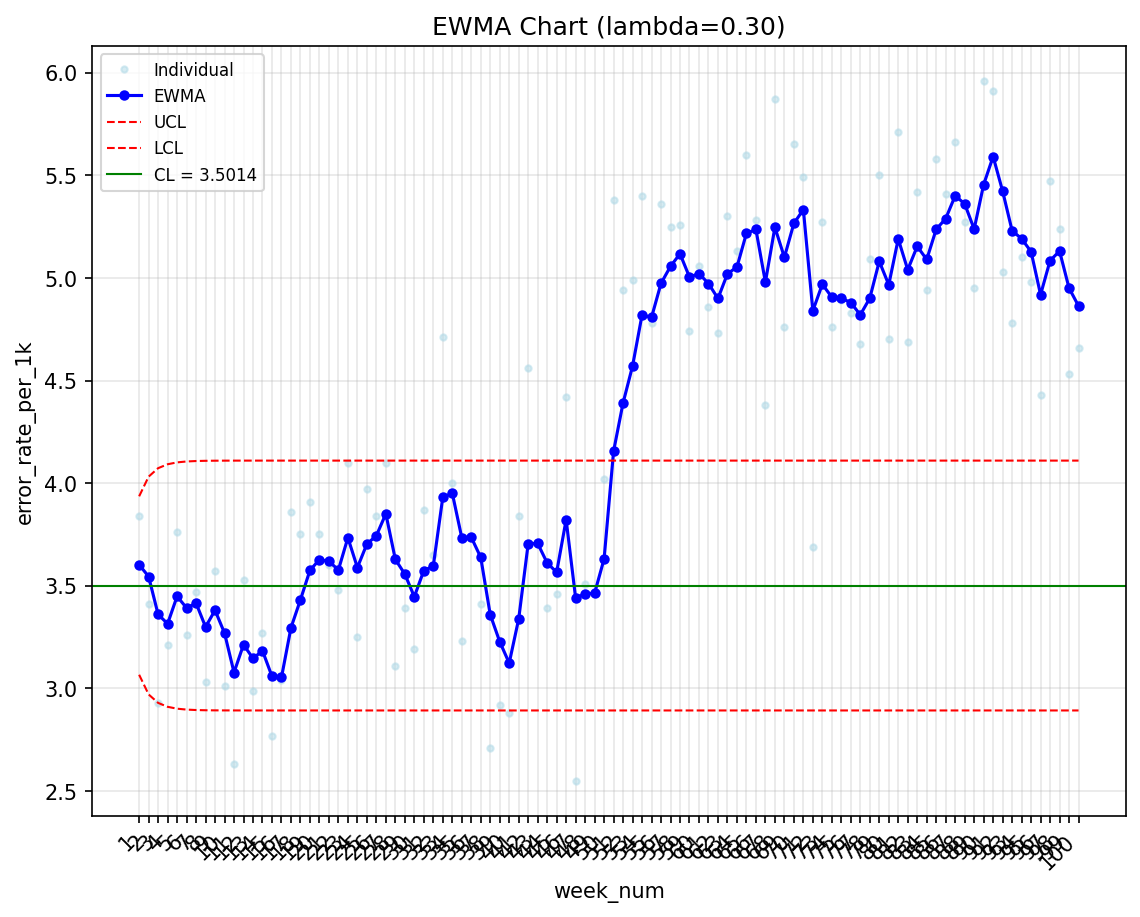

In [4]:
/* --------------------------------------------------------
   第二阶段：将完整的100周序列与固定的
   基线控制限进行对比监测。lambda=0.3可实现
   适合患者安全监测的灵敏检测。
   -------------------------------------------------------- */
过程 macontrol 数据=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        权重    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    标签 error_rate_per_1k =
          '每千次给药的用药错误数';
    标题 'EWMA控制图：ICU用药错误率（lambda=0.3）';
运行;

---

In [5]:
/* --------------------------------------------------------
   找出所有EWMA超出基线限值的周，
   并报告控制图首次发出信号的时间。
   -------------------------------------------------------- */
数据 work.signals;
    设置 work.icu_table;
    条件 _EXLIM_ ne ' ' 并且 _EXLIM_ ne '0';
运行;

过程 SQL;
    选择 count(*)        AS n_signals          标签='信号周数',
           MIN(week_num)    AS first_signal_week  标签='首次信号周',
           MAX(_EWMA_)      AS peak_ewma 格式=6.3 标签='EWMA峰值'
    FROM work.signals;
QUIT;

过程 打印 数据=work.signals(obs=8);
    变量 week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    标题 '首次失控的EWMA信号';
运行;

                                                  第一阶段控制限输入（基线第1-50周）                                                   

        信号周数            首次信号周      EWMA峰值
------------  ---------------  ----------
          50             51.0       5.591
                                                      首次失控的EWMA信号                                                       

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### 结果解读

两阶段EWMA分析清晰地将日常的周间波动与eMAR上线时真正发生的流程变化区分开来。

**基线期（第1-50周）。** PROC MEANS报告基线期平均错误率为**每千次给药3.50**（标准差0.48），迁移后平均为**5.11**（标准差0.44）——持续上移约**每千次1.6例错误**。两个阶段的给药量相当（每周795次对790次），因此这一变化反映的是错误*率*的变化，而非工作量的波动。

**控制限。** 控制限仅根据基线数据确定：中心线为**3.5014**，基线标准差为**0.4829**。在平滑权重lambda = 0.3和3-sigma限值下，EWMA上控制限收敛于其渐近值约**4.11**。在整个第1-50周期间，EWMA统计量始终位于该限值之内——基线期产生**零虚报**，说明该控制图并非过度敏感。

**检测。** 控制图在上线后的**第一周（第51周）**即发出失控信号，此时EWMA达到**4.156**，刚好超过4.11的限值。此后该统计量持续攀升，并在整个迁移后期间维持在上控制限之上：**全部50个迁移后周（第51-100周）均发出信号**，EWMA在第91周附近达到峰值**5.591**。lambda = 0.3的灵敏度意味着这一恶化趋势能被立即发现，而不必等到积累数周之后。

**行动建议。** 从eMAR上线当周开始的持续EWMA超限，是新系统——而非偶然——导致错误率上升的有力证据。患者安全委员会应将第51周视为变化点，审查该周引入的eMAR医嘱与越权流程，并持续用原始基线限值监测控制图，直至EWMA回落到4.11以下。导出的`icu_ewma_signals.csv`（50个信号周）和`icu_ewma_table.csv`为联合委员会（Joint Commission）持续合规审查提供了完整的SPC证据链。

---

In [6]:
/* --------------------------------------------------------
   导出EWMA数据表及信号列表，
   用于联合委员会（Joint Commission）持续合规文档。
   -------------------------------------------------------- */
过程 EXPORT 数据=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持：<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>